In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
data = pd.read_csv('dataset2/cb_multi_labeled_balanced.csv')

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99990 entries, 0 to 99989
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    99990 non-null  object
 1   label   99990 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [5]:
data.head()

,text,label
0,@ZubearSays Any real nigga isn't letting this ...,ethnicity/race
1,@MoradoSkittle @prolifejewess @DAConsult @Kell...,not_cyberbullying
2,"the only thing i wish, i wish a nigga would",ethnicity/race
3,You saudias are not friends of Muslim idiots c...,religion
4,@JaydenT2399 @TractorLaw @holmes_gael @erconge...,religion


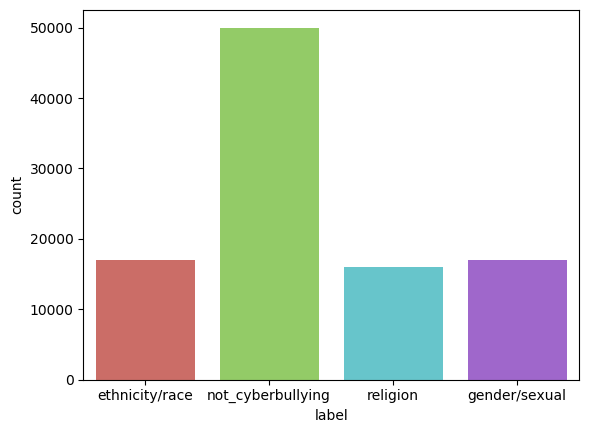

In [6]:
sns.countplot(x='label',data=data, palette='hls')
plt.show()
#plt.savefig('count_plot') mal: the nodule malignancy, 0: benign, 1: malignant

In [20]:
data['message'] = data['text']

In [8]:
from wordcloud import WordCloud, STOPWORDS
comment_words = ''
stopwords = set(STOPWORDS)

In [9]:
for val in data.message:
     
    # typecaste each val to string
    val = str(val)
 
    # split the value
    tokens = val.split()
     
    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()
     
    comment_words += " ".join(tokens)+" "

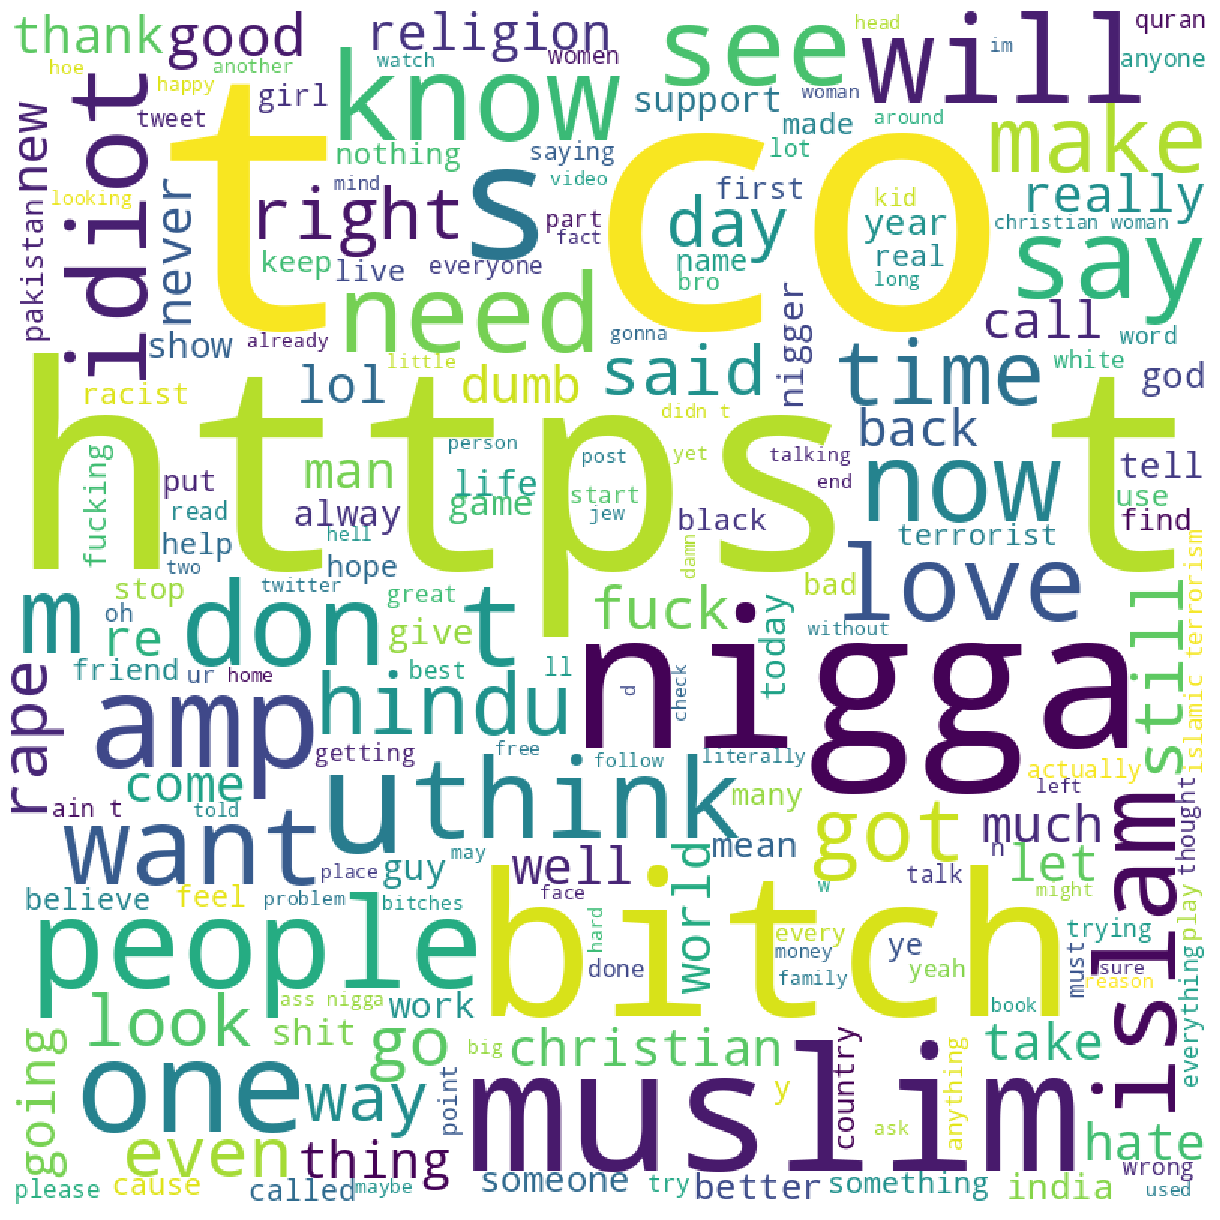

In [10]:
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(comment_words)

# plot the WordCloud image                      
plt.figure(figsize = (12, 12), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
 
plt.show()

In [8]:
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
import string 
from nltk.stem import WordNetLemmatizer

In [9]:
data['label'].value_counts()

not_cyberbullying    50000
ethnicity/race       17000
gender/sexual        17000
religion             15990
Name: label, dtype: int64

# Binary

In [22]:
def change_label(df):
  df['label'].replace(['religion','ethnicity/race','gender/sexual'],'cyberbullying',inplace=True)

In [23]:
change_label(data)

In [15]:
data['label'].value_counts()

not_cyberbullying    50000
cyberbullying        49990
Name: label, dtype: int64

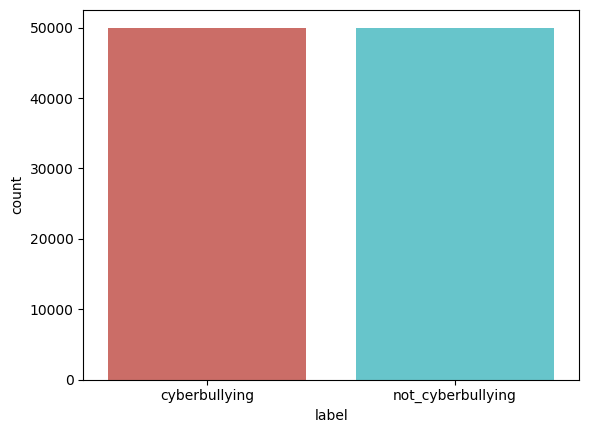

In [17]:
sns.countplot(x='label',data=data, palette='hls')
plt.show()

In [24]:
Tweet = []
Labels = []

for row in data["message"]:
    #tokenize words
    words = word_tokenize(row)
    #remove punctuations
    clean_words = [word.lower() for word in words if word not in set(string.punctuation)]
    #remove stop words
    english_stops = set(stopwords.words('english'))
    characters_to_remove = ["''",'``',"rt","https","’","“","”","\u200b","--","n't","'s","...","//t.c" ]
    clean_words = [word for word in clean_words if word not in english_stops]
    clean_words = [word for word in clean_words if word not in set(characters_to_remove)]
    #Lematise words
    wordnet_lemmatizer = WordNetLemmatizer()
    lemma_list = [wordnet_lemmatizer.lemmatize(word) for word in clean_words]
    Tweet.append(lemma_list)

In [25]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
data['label']= label_encoder.fit_transform(data['label'])

data['label'].unique()

array([0, 1])

In [26]:
X = data['message']
y = data['label']

In [27]:
# Extract Feature With CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(stop_words='english')
X = cv.fit_transform(X) # Fit the Data

In [28]:
from imblearn.over_sampling import SMOTE

In [29]:
smt = SMOTE()
X, y = smt.fit_resample(X, y)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [31]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(d, 3))
    recall.append(round(c, 3))
    f1score.append(round(b, 3))

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# SVM

In [33]:
from sklearn import svm
svc = svm.LinearSVC()
svc.fit(X_train, y_train)

y_pred    = svc.predict(X_test)

svc_acc = accuracy_score(y_pred, y_test)
svc_prec = precision_score(y_pred, y_test,average='weighted')
svc_rec = recall_score(y_pred, y_test,average='weighted')
svc_f1 = f1_score(y_pred, y_test,average='weighted')

In [34]:
storeResults('SVM',svc_acc,svc_prec,svc_rec,svc_f1)

# Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred    = rf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')

In [36]:
storeResults('RandomForest',rf_acc,rf_prec,rf_rec,rf_f1)

# Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
lr =  LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs')
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_test)

lr_acc = accuracy_score(y_pred, y_test)
lr_prec = precision_score(y_pred, y_test,average='weighted')
lr_rec = recall_score(y_pred, y_test,average='weighted')
lr_f1 = f1_score(y_pred, y_test,average='weighted')

In [38]:
storeResults('LogisticRegression',lr_acc,lr_prec,lr_rec,lr_f1)

# MLP - OVO

In [39]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.neural_network import MLPClassifier

mlp = OneVsOneClassifier(MLPClassifier(random_state=1))

mlp.fit(X_train, y_train)

y_pred    = mlp.predict(X_test)

mlp_acc = accuracy_score(y_pred, y_test)
mlp_prec = precision_score(y_pred, y_test,average='weighted')
mlp_rec = recall_score(y_pred, y_test,average='weighted')
mlp_f1 = f1_score(y_pred, y_test,average='weighted')

In [40]:
storeResults('MLP-OVO',mlp_acc,mlp_prec,mlp_rec,mlp_f1)

# MLP - OVR

In [41]:
from sklearn.multiclass import OneVsRestClassifier
mlp = OneVsRestClassifier(MLPClassifier(random_state=1))

mlp.fit(X_train, y_train)

y_pred    = mlp.predict(X_test)

mlp1_acc = accuracy_score(y_pred, y_test)
mlp1_prec = precision_score(y_pred, y_test,average='weighted')
mlp1_rec = recall_score(y_pred, y_test,average='weighted')
mlp1_f1 = f1_score(y_pred, y_test,average='weighted')

In [42]:
storeResults('MLP-OVR',mlp1_acc,mlp1_prec,mlp1_rec,mlp1_f1)

# Extension

In [43]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

brf = BaggingClassifier(RandomForestClassifier())

bdt = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1))

model = VotingClassifier(estimators= [('BoostDT', bdt),('BagRF', brf)], voting='soft')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

ext_acc = accuracy_score(y_pred, y_test)
ext_prec = precision_score(y_pred, y_test,average='weighted')
ext_rec = recall_score(y_pred, y_test,average='weighted')
ext_f1 = f1_score(y_pred, y_test,average='weighted')

In [44]:
storeResults('Extension',ext_acc,ext_prec,ext_rec,ext_f1)

# Comparison

In [45]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score 
                      }) 

In [46]:
result

,ML Model,Accuracy,Precision,Recall,F1_score
0,SVM,0.988,0.987,0.988,0.988
1,RandomForest,0.993,0.993,0.993,0.993
2,LogisticRegression,0.978,0.978,0.978,0.979
3,MLP-OVO,0.489,0.657,0.489,1.000
4,MLP-OVR,0.968,0.968,0.968,0.970
5,Extension,1.000,1.000,1.000,1.000


# Modelling

In [48]:
import pickle
pickle.dump(cv, open("data2_bin.pickle", "wb"))

In [49]:
import joblib
filename = 'model_data2_bin.sav'
joblib.dump(model, filename)

['model_data2_bin.sav']

# Graph

In [50]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

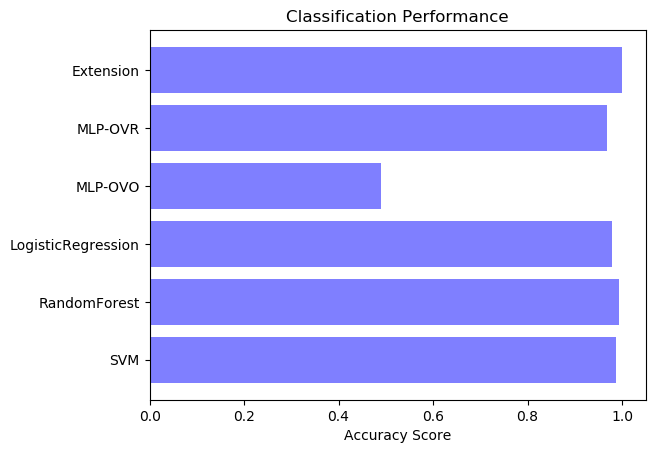

In [51]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

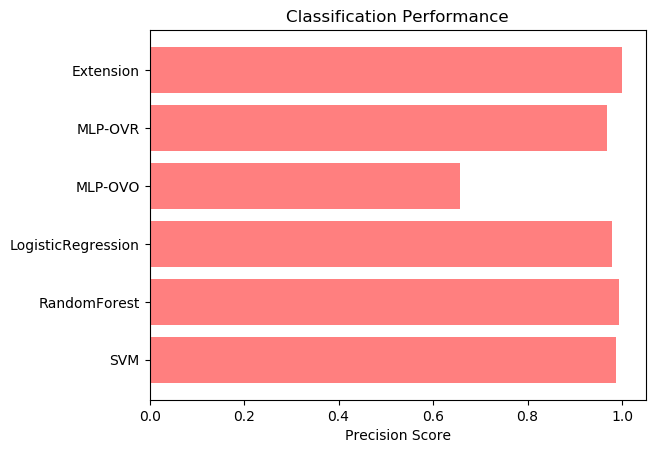

In [52]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

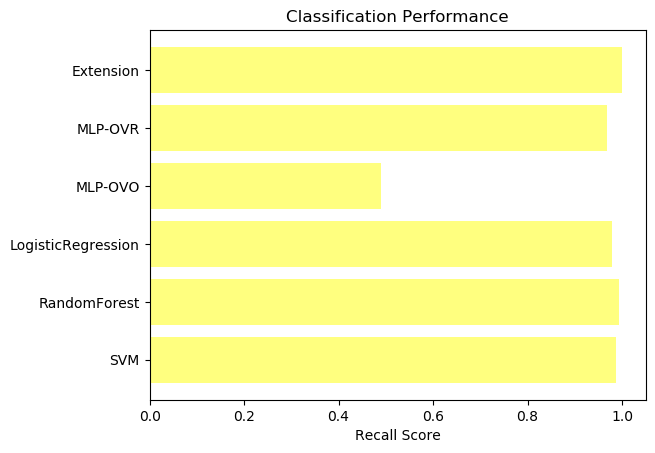

In [53]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

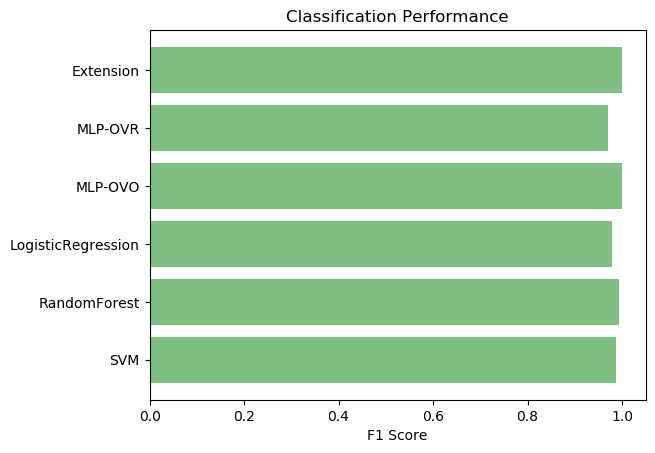

In [54]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# Multi-Class

In [55]:
data = pd.read_csv('dataset2/cb_multi_labeled_balanced.csv')

In [57]:
data['message'] = data['text']

In [58]:
#print(data.info())
data = pd.concat([
    data[data.label == 'ethnicity/race'].sample(n=10_00),
    data[data.label == 'gender/sexual'].sample(n=10_00),
    data[data.label == 'religion'].sample(n=10_00),
    data[data.label == 'not_cyberbullying'].sample(n=10_00)
])

In [59]:
Tweet = []
Labels = []

for row in data["message"]:
    #tokenize words
    words = word_tokenize(row)
    #remove punctuations
    clean_words = [word.lower() for word in words if word not in set(string.punctuation)]
    #remove stop words
    english_stops = set(stopwords.words('english'))
    characters_to_remove = ["''",'``',"rt","https","’","“","”","\u200b","--","n't","'s","...","//t.c" ]
    clean_words = [word for word in clean_words if word not in english_stops]
    clean_words = [word for word in clean_words if word not in set(characters_to_remove)]
    #Lematise words
    wordnet_lemmatizer = WordNetLemmatizer()
    lemma_list = [wordnet_lemmatizer.lemmatize(word) for word in clean_words]
    Tweet.append(lemma_list)

In [60]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
data['label']= label_encoder.fit_transform(data['label'])

data['label'].unique()

array([0, 1, 3, 2])

In [61]:
X = data['message']
y = data['label']

In [62]:
# Extract Feature With CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(stop_words='english')
X = cv.fit_transform(X) # Fit the Data

In [63]:
smt = SMOTE()
X, y = smt.fit_resample(X, y)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [65]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(d, 3))
    recall.append(round(c, 3))
    f1score.append(round(b, 3))

# SVM

In [66]:
svc = svm.LinearSVC()
svc.fit(X_train, y_train)

y_pred    = svc.predict(X_test)

svc_acc = accuracy_score(y_pred, y_test)
svc_prec = precision_score(y_pred, y_test,average='weighted')
svc_rec = recall_score(y_pred, y_test,average='weighted')
svc_f1 = f1_score(y_pred, y_test,average='weighted')

In [67]:
storeResults('SVM',svc_acc,svc_prec,svc_rec,svc_f1)

# Random Forest

In [68]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred    = rf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')

In [69]:
storeResults('RandomForest',rf_acc,rf_prec,rf_rec,rf_f1)

# LogisticRegression

In [70]:
lr =  LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs')
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_test)

lr_acc = accuracy_score(y_pred, y_test)
lr_prec = precision_score(y_pred, y_test,average='weighted')
lr_rec = recall_score(y_pred, y_test,average='weighted')
lr_f1 = f1_score(y_pred, y_test,average='weighted')

In [71]:
storeResults('LogisticRegression',lr_acc,lr_prec,lr_rec,lr_f1)

# MLP - OVO

In [72]:
mlp = OneVsOneClassifier(MLPClassifier(random_state=1))

mlp.fit(X_train, y_train)

y_pred    = mlp.predict(X_test)

mlp_acc = accuracy_score(y_pred, y_test)
mlp_prec = precision_score(y_pred, y_test,average='weighted')
mlp_rec = recall_score(y_pred, y_test,average='weighted')
mlp_f1 = f1_score(y_pred, y_test,average='weighted')

In [73]:
storeResults('MLP-OVO',mlp_acc,mlp_prec,mlp_rec,mlp_f1)

# MLP - OVR

In [74]:
mlp = OneVsRestClassifier(MLPClassifier(random_state=1))

mlp.fit(X_train, y_train)

y_pred    = mlp.predict(X_test)

mlp1_acc = accuracy_score(y_pred, y_test)
mlp1_prec = precision_score(y_pred, y_test,average='weighted')
mlp1_rec = recall_score(y_pred, y_test,average='weighted')
mlp1_f1 = f1_score(y_pred, y_test,average='weighted')

In [75]:
storeResults('MLP-OVR',mlp1_acc,mlp1_prec,mlp1_rec,mlp1_f1)

# Extension

In [76]:
model = VotingClassifier(estimators= [('BoostDT', bdt),('BagRF', brf)], voting='soft')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

ext_acc = accuracy_score(y_pred, y_test)
ext_prec = precision_score(y_pred, y_test,average='weighted')
ext_rec = recall_score(y_pred, y_test,average='weighted')
ext_f1 = f1_score(y_pred, y_test,average='weighted')

In [77]:
storeResults('Extension',ext_acc,ext_prec,ext_rec,ext_f1)

# Comparison

In [78]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score 
                      }) 

In [79]:
result

,ML Model,Accuracy,Precision,Recall,F1_score
0,SVM,0.976,0.976,0.976,0.977
1,RandomForest,0.981,0.981,0.981,0.981
2,LogisticRegression,0.935,0.934,0.935,0.940
3,MLP-OVO,0.532,0.607,0.532,0.721
4,MLP-OVR,0.715,0.723,0.715,0.765
5,Extension,0.997,0.997,0.997,0.997


# Modelling

In [81]:
import pickle
pickle.dump(cv, open("data2_multi.pickle", "wb"))

In [82]:
import joblib
filename = 'model_data2_multi.sav'
joblib.dump(model, filename)

['model_data2_multi.sav']

# Graph

In [83]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

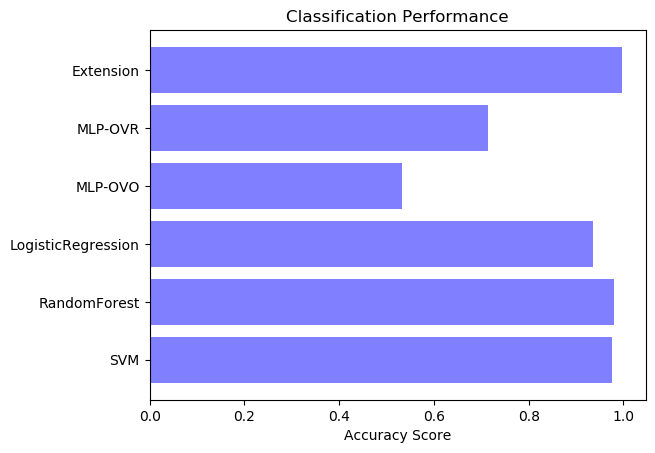

In [84]:
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Preicision

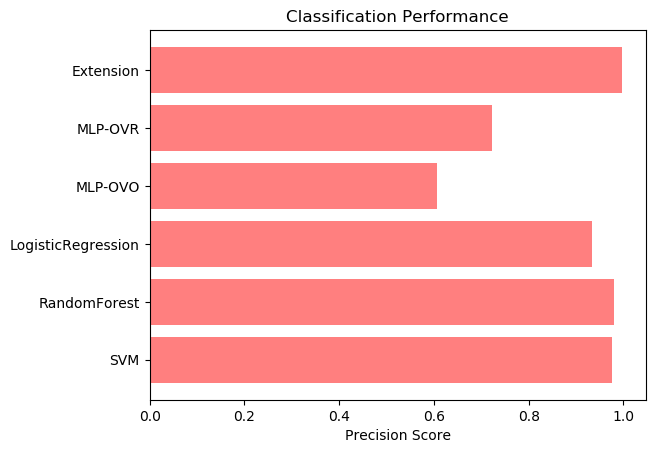

In [85]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

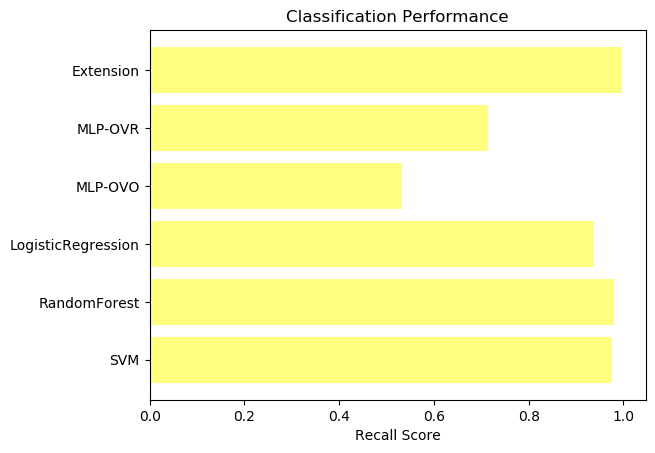

In [86]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

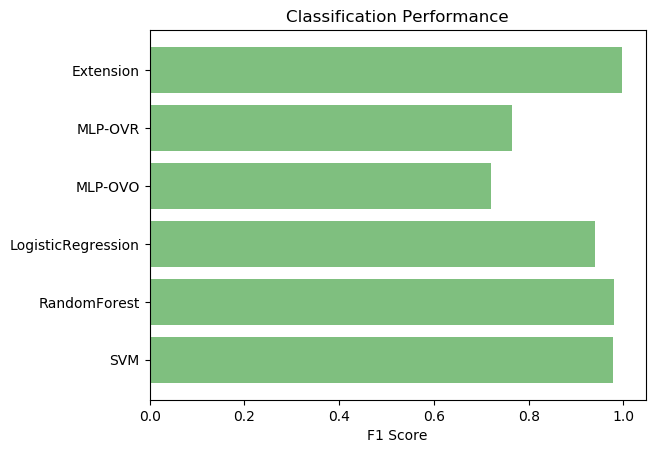

In [87]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()